Simple chain that combines 4 key concepts

Using chat messages in our graph
Using chat models
Binding tools to our LLM
Executing tool claas in our graph

In [4]:
%%capture --no-stderr

UsageError: %%capture is a cell magic, but the cell body is empty.


In [8]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

messages = [AIMessage(content="Hello, how are you?", name="assistant")]
messages.extend([HumanMessage(content="I'm doing great, thank you!", name="user")])

# pprint(messages)

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: assistant

Hello, how are you?
================================ Human Message =================================
Name: user

I'm doing great, thank you!


Chat Models

We will be using the gemini llm (gemini-2.0-flash-lite)

In [1]:
import getpass
import os
def _set_env(var_name: str):
    if not os.environ.get("GOOGLE_API_KEY"):
    
       os.environ[var_name] = getpass.getpass(f"Enter your {var_name}: ")

_set_env(var_name="GOOGLE_API_KEY")


In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-lite")
result = llm.invoke("What is the capital of France?")
type(result)

langchain_core.messages.ai.AIMessage

In [8]:
result.usage_metadata

{'input_tokens': 7,
 'output_tokens': 9,
 'total_tokens': 16,
 'input_token_details': {'cache_read': 0}}

Tools

In [10]:
def multiply(a: int, b: int) -> int:
    """
    Multiply two numbers together.

    Args:
        a: The first number to multiply.
        b: The second number to multiply.

    Returns:
        The product of the two numbers.
    """
    return a * b



In [11]:
llm_with_tools = llm.bind_tools([multiply])

In [12]:
from langchain_core.messages import HumanMessage

message_for_tool = HumanMessage(content=f"What is 23 multiplied by 25", name="user")
message_for_tool


HumanMessage(content='What is 23 multiplied by 25', additional_kwargs={}, response_metadata={}, name='user')

In [14]:
tool_call = llm_with_tools.invoke([message_for_tool])
tool_call

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 23.0, "b": 25.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-lite', 'safety_ratings': []}, id='run--a271fb71-2e2c-490e-8f17-91cc98b82920-0', tool_calls=[{'name': 'multiply', 'args': {'a': 23.0, 'b': 25.0}, 'id': '5e18826c-09ee-4ae0-bcbc-fd71dc3d3afb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 35, 'output_tokens': 5, 'total_tokens': 40, 'input_token_details': {'cache_read': 0}})

In [15]:
tool_call.additional_kwargs

{'function_call': {'name': 'multiply', 'arguments': '{"a": 23.0, "b": 25.0}'}}

Using messages as state

In [18]:
from typing import TypedDict
from langchain_core.messages import AnyMessage

class MessageState(TypedDict):
    messages: list[AnyMessage]

Reducers

As graph run we want to append the messages to our messages state key

but the problem is each node will override the prior state value.

Reducer functions address this

In [19]:
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]



This is also pre-buit in Langgraph

from langgraph.graph import MessagesState

In [29]:
from langgraph.graph import MessagesState

class MessageState(MessagesState):
    pass


In [21]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph import MessagesState

class MessageState(MessagesState):
    pass

initial_messages = [AIMessage(content="Hello, how can I assist you?", name="assistant"),
                    HumanMessage(content="I am looking for information related to marine ecosystem", name="user")]

new_message = HumanMessage(content="Sure, I can welp with that. What specifically are you looking for or interested in.", name="user")

add_messages(initial_messages, new_message)

[AIMessage(content='Hello, how can I assist you?', additional_kwargs={}, response_metadata={}, name='assistant', id='133263b1-207c-4a14-921c-dc12ad572ea5'),
 HumanMessage(content='I am looking for information related to marine ecosystem', additional_kwargs={}, response_metadata={}, name='user', id='4c86070d-f48e-478d-8e01-eb5410fd99b0'),
 HumanMessage(content='Sure, I can welp with that. What specifically are you looking for or interested in.', additional_kwargs={}, response_metadata={}, name='user', id='d0998dc7-d515-4d1b-86ef-3fa941b255bb')]

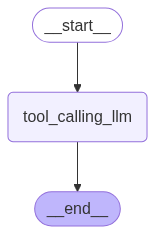

In [26]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

# State
class MessageState(MessagesState):
    pass

# Node
def tool_calling_llm(state: MessageState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Graph 
builder = StateGraph(MessageState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
# graph.invoke(initial_messages)

In [27]:
messages = graph.invoke({
    "messages": HumanMessage(content="Hello", name="user")
})
messages

{'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, name='user', id='557024b1-9dd2-49b3-9c2e-bc20ae91f83a'),
  AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-lite', 'safety_ratings': []}, id='run--9ce7b9a7-68a6-4cbe-845c-34f5b596afc7-0', usage_metadata={'input_tokens': 26, 'output_tokens': 11, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}})]}

In [28]:
messages = graph.invoke({
    "messages": HumanMessage(content="Multiply 57 with 23", name="user")
})

messages

{'messages': [HumanMessage(content='Multiply 57 with 23', additional_kwargs={}, response_metadata={}, name='user', id='1dbc9659-3769-460a-a693-ebda405dd8e2'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 57.0, "b": 23.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-lite', 'safety_ratings': []}, id='run--01faca7d-2cf1-4d17-968c-cb9d073930fe-0', tool_calls=[{'name': 'multiply', 'args': {'a': 57.0, 'b': 23.0}, 'id': '04826cd7-032d-460e-8e74-b0f7933e6994', 'type': 'tool_call'}], usage_metadata={'input_tokens': 33, 'output_tokens': 5, 'total_tokens': 38, 'input_token_details': {'cache_read': 0}})]}